# Machine Learning and Explainable AI for Residential Property Valuation in Dubai

Libraries Import

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Explainable AI
import shap

# Model Exporting (for Streamlit later)
import joblib

# Suppress warnings for clean notebook output
import warnings
warnings.filterwarnings('ignore')

# Set basic plot style
sns.set_theme(style="whitegrid")

C:\Users\Syed Haider Ali\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Syed Haider Ali\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Loading DataSet

In [ ]:
# Define the file path 
file_path = 'Transactions.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows to verify the data loaded correctly
display(df.head())

# Print the structural information (column names, non-null counts, and data types)
df.info()

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,1-11-2001-165,11,1,مبايعات,Sales,بيع,Sell,24-02-2001,1,أرض,...,NaN,0,1393.55,1350000.0,968.75,NaN,NaN,1.0,1.0,0.0
1,3-9-2004-223,9,3,هبات,Gifts,هبه,Grant,13-12-2004,4,فيلا,...,NaN,0,1728.00,2790000.0,1614.58,NaN,NaN,1.0,1.0,0.0
2,2-13-1996-119,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,12-03-2001,1,أرض,...,NaN,0,929.03,20000000.0,21527.83,NaN,NaN,1.0,1.0,0.0
3,2-14-2005-222,14,2,رهون,Mortgages,تعديل رهن,Modify Mortgage,20-09-2005,2,مبنى,...,NaN,0,2673.28,25000000.0,9351.81,NaN,NaN,1.0,1.0,0.0
4,3-9-2012-874,9,3,هبات,Gifts,هبه,Grant,11-10-2012,4,فيلا,...,NaN,0,1541.17,9000000.0,5839.72,NaN,NaN,1.0,1.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 1047965 entries, 0 to 1047964
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1047965 non-null  str    
 1   procedure_id          1047965 non-null  int64  
 2   trans_group_id        1047965 non-null  int64  
 3   trans_group_ar        1047965 non-null  str    
 4   trans_group_en        1047965 non-null  str    
 5   procedure_name_ar     1047965 non-null  str    
 6   procedure_name_en     1047965 non-null  str    
 7   instance_date         1047960 non-null  str    
 8   property_type_id      1047965 non-null  int64  
 9   property_type_ar      1047965 non-null  str    
 10  property_type_en      1047965 non-null  str    
 11  property_sub_type_id  807819 non-null   float64
 12  property_sub_type_ar  807819 non-null   str    
 13  property_sub_type_en  807819 non-null   str    
 14  property_usage_ar     1047965 non-null  str  

# Data Cleaning

Filtering and Column Selection

In [3]:
# --- 1. FILTERING & SELECTION ---

# Keep only actual "Sell" transactions
df_clean = df[df['procedure_name_en'] == 'Sell'].copy()

# Keep only residential property types (In DLD, 'Unit' usually means Apartment)
valid_types = ['Unit', 'Villa']
df_clean = df_clean[df_clean['property_type_en'].isin(valid_types)]

# Select only the specific columns needed for your predictive models
columns_to_keep = [
    'actual_worth',
    'procedure_area',
    'property_type_en',
    'area_name_en',
    'rooms_en',
    'has_parking',
    'instance_date'
]
df_clean = df_clean[columns_to_keep]

# Group rare areas into 'Other'
area_counts = df_clean['area_name_en'].value_counts()
top_areas = area_counts[area_counts >= 100].index
df_clean['area_name_en'] = df_clean['area_name_en'].apply(
    lambda x: x if x in top_areas else 'Other'
)
print(f"Unique areas after grouping: {df_clean['area_name_en'].nunique()}")

Unique areas after grouping: 83


Handling Duplicates and Missing Values

In [4]:
# --- 2. DUPLICATES & MISSING VALUES ---

# Drop duplicate transaction records
df_clean = df_clean.drop_duplicates()

# Drop rows where the target (Price), Size, or Location is fundamentally missing
df_clean = df_clean.dropna(subset=['actual_worth', 'procedure_area', 'area_name_en'])

# Clean bedroom column (DLD often uses text like '1 B/R' or 'Studio'. We extract the number and make Studio = 0)
df_clean['rooms_en'] = df_clean['rooms_en'].astype(str).str.extract(r'(\d+)').fillna(0).astype(int)

# Fill missing parking values with 0 (Assuming NaN means no parking)
df_clean['has_parking'] = df_clean['has_parking'].fillna(0).astype(int)
# Extract year and month from transaction date
df_clean['transaction_year'] = pd.to_datetime(df_clean['instance_date'], dayfirst=True).dt.year
df_clean['transaction_month'] = pd.to_datetime(df_clean['instance_date'], dayfirst=True).dt.month
df_clean = df_clean.drop(columns=['instance_date'])

print("Time features added successfully.")
print(df_clean[['transaction_year', 'transaction_month']].head())

print("Time features added successfully.")
print(df_clean[['transaction_year', 'transaction_month']].head())
print(f"Rows remaining after cleaning: {len(df_clean)}")
print("\nMissing values check:")
print(df_clean.isnull().sum())


Time features added successfully.
    transaction_year  transaction_month
26              2007                  1
27              2014                  6
30              2012                 11
31              2005                 11
35              2008                  4
Time features added successfully.
    transaction_year  transaction_month
26              2007                  1
27              2014                  6
30              2012                 11
31              2005                 11
35              2008                  4
Rows remaining after cleaning: 294917

Missing values check:
actual_worth         0
procedure_area       0
property_type_en     0
area_name_en         0
rooms_en             0
has_parking          0
transaction_year     0
transaction_month    0
dtype: int64


Categorical Encoding

In [ ]:
# --- 3. CATEGORICAL ENCODING ---

# Rename 'Unit' to 'Apartment' for better readability 
df_clean['property_type_en'] = df_clean['property_type_en'].replace({'Unit': 'Apartment'})

# One-Hot Encode the categorical variables (Type and Location)
# drop_first=True prevents the dummy variable trap (multicollinearity)
df_encoded = pd.get_dummies(df_clean, columns=['property_type_en', 'area_name_en'], drop_first=True)

# Ensure all boolean columns created by get_dummies are integers (1 or 0)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Display the final preprocessed dataframe
print(f"Final Preprocessed Shape: {df_encoded.shape}")
display(df_encoded.head())

Final Preprocessed Shape: (294917, 89)


,actual_worth,procedure_area,rooms_en,has_parking,transaction_year,transaction_month,property_type_en_Villa,area_name_en_Al Bada,area_name_en_Al Barsha First,area_name_en_Al Barsha Second,...,area_name_en_Um Hurair Second,area_name_en_Um Suqaim First,area_name_en_Um Suqaim Second,area_name_en_Um Suqaim Third,area_name_en_Wadi Al Safa 2,area_name_en_Wadi Al Safa 3,area_name_en_Wadi Al Safa 5,area_name_en_Wadi Al Safa 6,area_name_en_Wadi Al Safa 7,area_name_en_Warsan Fourth
26,4088150.0,1381.10,0,0,2007,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27,1500000.0,346.16,0,0,2014,6,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30,7040150.0,2012.50,0,0,2012,11,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31,1500000.0,696.77,0,0,2005,11,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35,7300000.0,1393.55,0,0,2008,4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Exploratory Data Analysis (EDA)

Descriptive Stats & Price Distribution

--- Descriptive Statistics ---


,actual_worth,procedure_area,rooms_en
count,294917.00,294917.00,294917.00
mean,1801429.74,224.87,1.09
std,2686809.40,737.74,1.14
min,1.00,0.13,0.00
25%,589389.00,69.00,0.00
50%,1111888.00,107.90,1.00
75%,2091880.00,194.52,2.00
max,92000000.00,207934.38,8.00


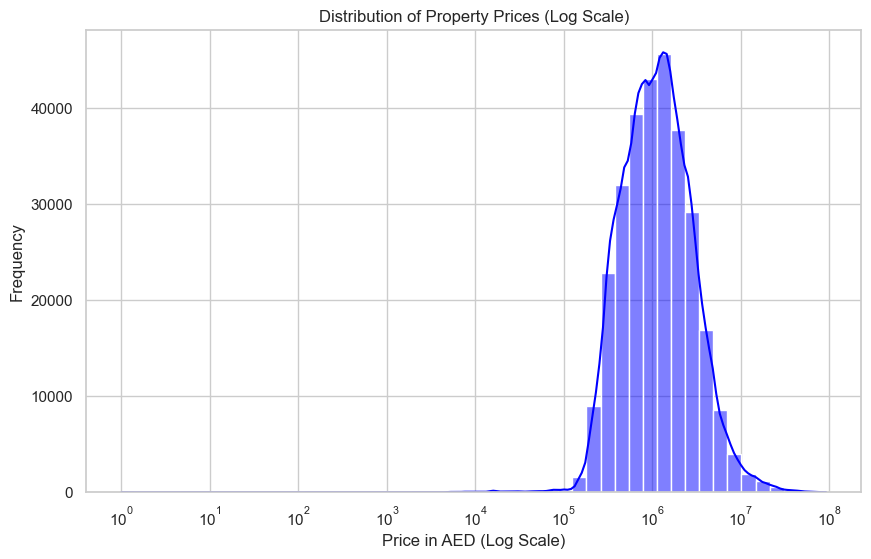

In [6]:
# --- PHASE 2: EDA - DISTRIBUTIONS ---

# 1. Print basic descriptive statistics for numerical columns
print("--- Descriptive Statistics ---")
display(df_clean[['actual_worth', 'procedure_area', 'rooms_en']].describe().apply(lambda s: s.apply('{0:.2f}'.format)))

# 2. Plot the distribution of Property Prices
plt.figure(figsize=(10, 6))
# Using a log scale because real estate prices usually have massive outliers (multi-million dirham mansions)
sns.histplot(df_clean['actual_worth'], bins=50, kde=True, log_scale=True, color='blue')
plt.title('Distribution of Property Prices (Log Scale)')
plt.xlabel('Price in AED (Log Scale)')
plt.ylabel('Frequency')
plt.show()

Correlation Analysis & Size vs. Price

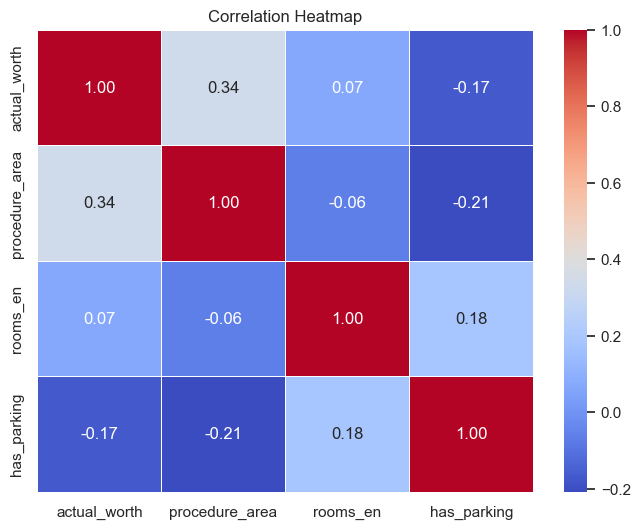

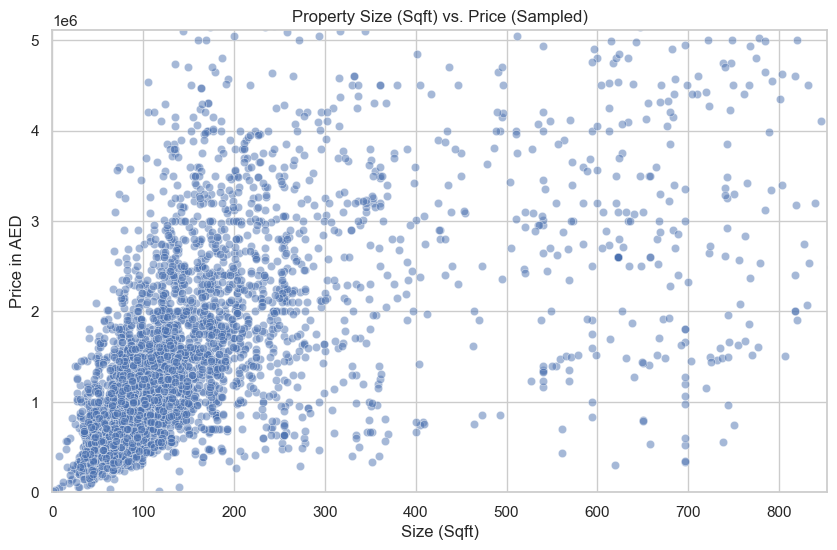

In [7]:
# --- PHASE 2: EDA - CORRELATIONS & SCATTER ---

# 1. Correlation Heatmap for continuous/numerical variables
plt.figure(figsize=(8, 6))
numerical_features = df_clean[['actual_worth', 'procedure_area', 'rooms_en', 'has_parking']]
correlation_matrix = numerical_features.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 2. Scatter plot: Property Size vs Price
plt.figure(figsize=(10, 6))
# Taking a random sample of 5000 rows so the plot renders quickly and isn't a solid block of ink
sns.scatterplot(data=df_clean.sample(5000, random_state=42), x='procedure_area', y='actual_worth', alpha=0.5)
plt.title('Property Size (Sqft) vs. Price (Sampled)')
plt.xlabel('Size (Sqft)')
plt.ylabel('Price in AED')
# Limiting axes slightly to zoom in past extreme outliers for better visibility
plt.ylim(0, df_clean['actual_worth'].quantile(0.95))
plt.xlim(0, df_clean['procedure_area'].quantile(0.95))
plt.show()

Categorical & Geographic Trends

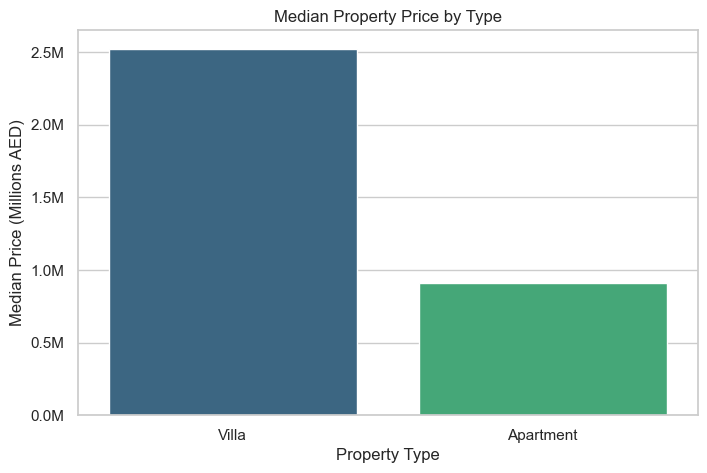

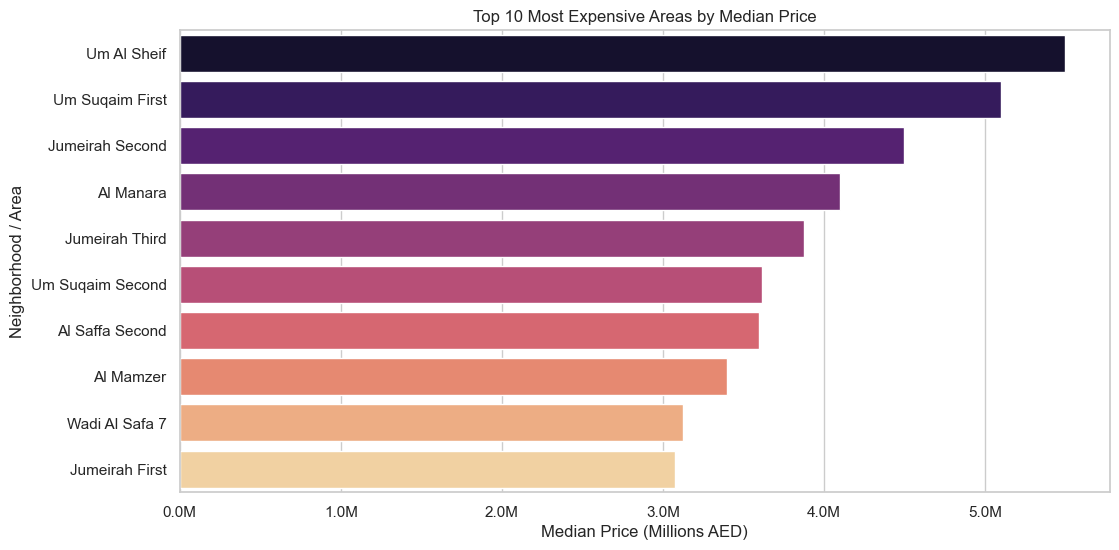

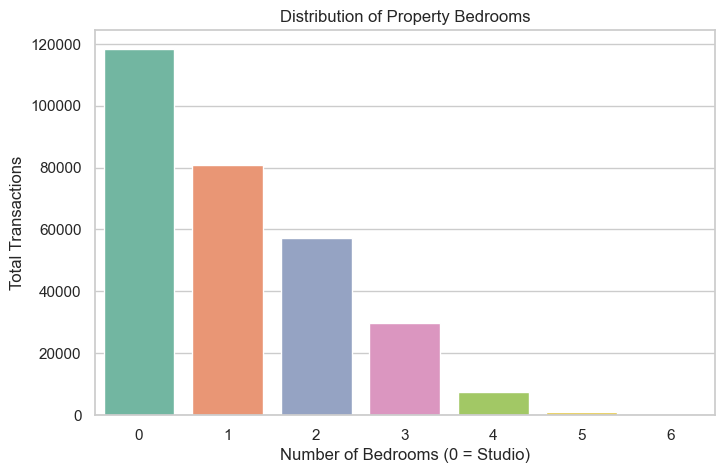

In [8]:
# --- PHASE 2: EDA - CATEGORIES & LOCATIONS ---

# 1. Median Price by Property Type (Apartment vs. Villa)
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='property_type_en', y='actual_worth', estimator=np.median, errorbar=None, palette='viridis')
plt.title('Median Property Price by Type')
plt.xlabel('Property Type')
plt.ylabel('Median Price (Millions AED)')
# Format the Y-axis to show millions cleanly (e.g., 2.5M instead of 2500000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.1f}M".format(x/1000000)))
plt.show()

# 2. Top 10 Most Expensive Neighborhoods (Proves H2 regarding Location)
plt.figure(figsize=(12, 6))
# Find the top 10 areas with the highest median price
top_10_areas = df_clean.groupby('area_name_en')['actual_worth'].median().sort_values(ascending=False).head(10).index
# Plot just those top 10 areas
sns.barplot(data=df_clean[df_clean['area_name_en'].isin(top_10_areas)], 
            x='actual_worth', y='area_name_en', order=top_10_areas, estimator=np.median, errorbar=None, palette='magma')
plt.title('Top 10 Most Expensive Areas by Median Price')
plt.xlabel('Median Price (Millions AED)')
plt.ylabel('Neighborhood / Area')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.1f}M".format(x/1000000)))
plt.show()

# 3. Distribution of Bedrooms (Validating property characteristics)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='rooms_en', palette='Set2')
plt.title('Distribution of Property Bedrooms')
plt.xlabel('Number of Bedrooms (0 = Studio)')
plt.ylabel('Total Transactions')
# Zoom in on standard residential sizes (Studios to 6 Bedrooms) to avoid a skewed graph
plt.xlim(-0.5, 6.5) 
plt.show()

Outlier Detection

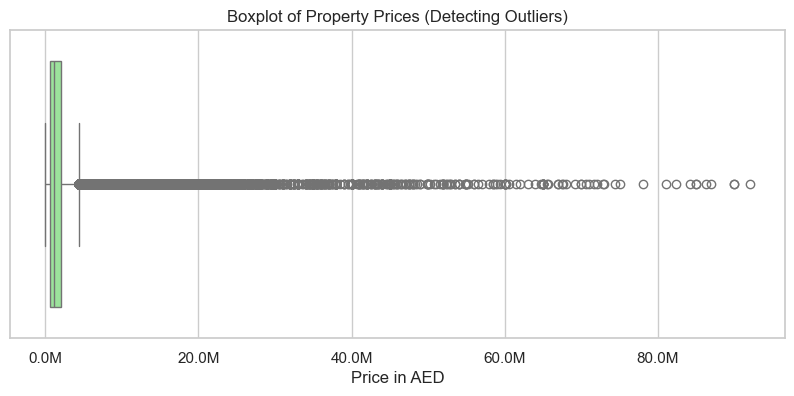

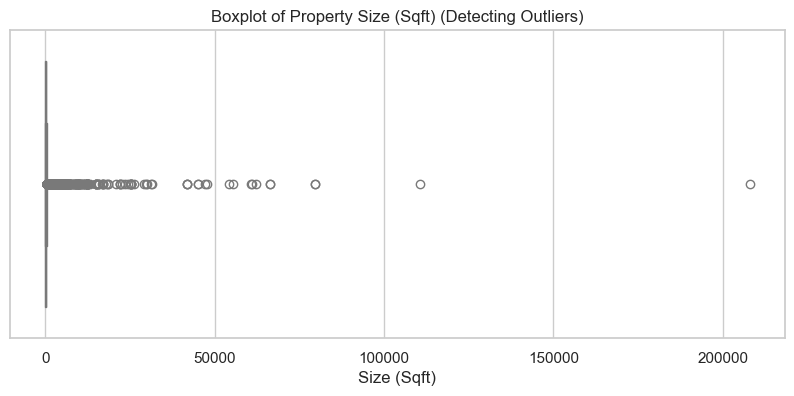

In [9]:
# --- PHASE 2: EDA - OUTLIER DETECTION ---

# 1. Boxplot for Property Prices
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['actual_worth'], color='lightgreen')
plt.title('Boxplot of Property Prices (Detecting Outliers)')
plt.xlabel('Price in AED')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.1f}M".format(x/1000000)))
plt.show()

# 2. Boxplot for Property Size
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['procedure_area'], color='lightblue')
plt.title('Boxplot of Property Size (Sqft) (Detecting Outliers)')
plt.xlabel('Size (Sqft)')
plt.show()

Feature Interactions & Amenities

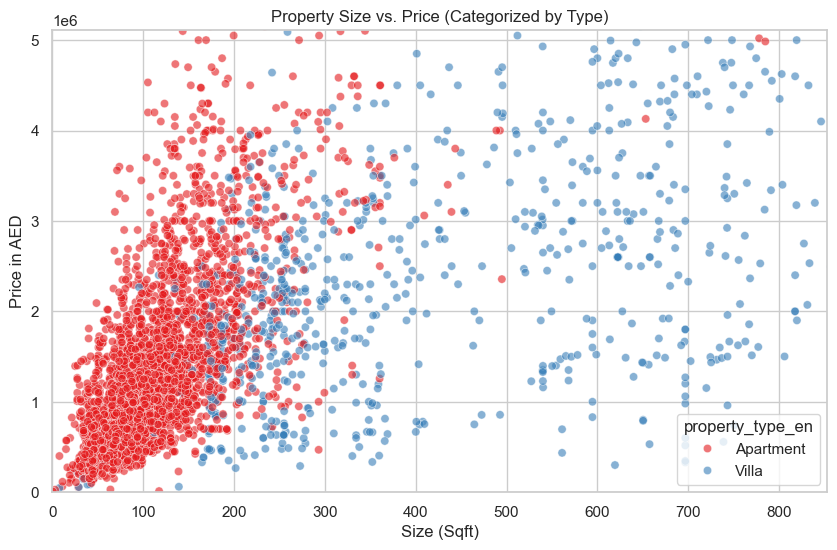

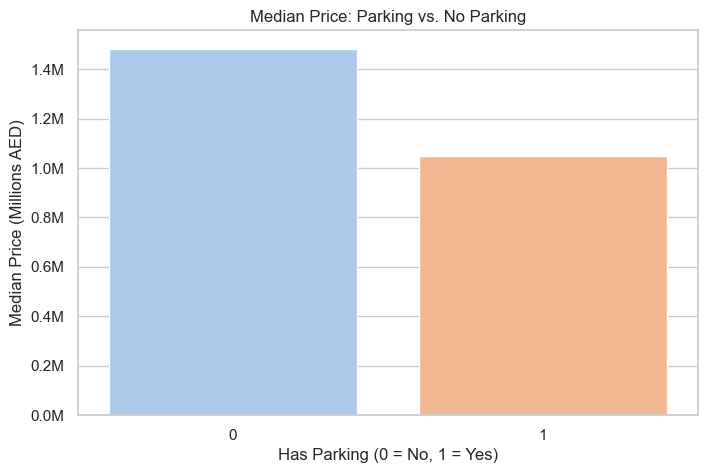

In [10]:
# --- PHASE 2: EDA - MULTIVARIATE & AMENITIES ---

# 1. Size vs Price colored by Property Type
plt.figure(figsize=(10, 6))
# Sampled to 5000 rows for rendering performance
sns.scatterplot(data=df_clean.sample(5000, random_state=42), 
                x='procedure_area', y='actual_worth', hue='property_type_en', alpha=0.6, palette='Set1')
plt.title('Property Size vs. Price (Categorized by Type)')
plt.xlabel('Size (Sqft)')
plt.ylabel('Price in AED')
plt.ylim(0, df_clean['actual_worth'].quantile(0.95))
plt.xlim(0, df_clean['procedure_area'].quantile(0.95))
plt.show()

# 2. Impact of Parking on Property Price
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='has_parking', y='actual_worth', estimator=np.median, errorbar=None, palette='pastel')
plt.title('Median Price: Parking vs. No Parking')
plt.xlabel('Has Parking (0 = No, 1 = Yes)')
plt.ylabel('Median Price (Millions AED)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.1f}M".format(x/1000000)))
plt.show()

Removing the Top 1% Outliers

In [11]:
# --- OUTLIER REMOVAL ---

# Calculate the 99th percentile thresholds
price_threshold = df_encoded['actual_worth'].quantile(0.99)
size_threshold = df_encoded['procedure_area'].quantile(0.99)

# Filter out the extreme top 1% for both price and size
df_filtered = df_encoded[(df_encoded['actual_worth'] <= price_threshold) & 
                         (df_encoded['procedure_area'] <= size_threshold)].copy()

print(f"Rows before outlier removal: {len(df_encoded)}")
print(f"Rows after removing top 1%: {len(df_filtered)}")

Rows before outlier removal: 294917
Rows after removing top 1%: 289987


# Feature Engineering

Engineering New Metrics

In [12]:
# --- PHASE 3: FEATURE ENGINEERING ---

# Create the Price per Square Foot variable
df_filtered['price_per_sqft'] = df_filtered['actual_worth'] / df_filtered['procedure_area']

# Round to 2 decimal places for cleaner data
df_filtered['price_per_sqft'] = df_filtered['price_per_sqft'].round(2)
# Display the new feature alongside its parent variables to verify
print("Feature Engineering Complete. Verifying new metric:")
display(df_filtered[['actual_worth', 'procedure_area', 'price_per_sqft']].head())
# Area Mean Price Encoding (smarter location signal than 135 dummies)
area_price_map = df_clean.groupby('area_name_en')['actual_worth'].mean()
df_clean['area_mean_price'] = df_clean['area_name_en'].map(area_price_map)
df_filtered['area_mean_price'] = df_clean.loc[df_filtered.index, 'area_mean_price']

print("Area mean price encoding added.")
display(df_filtered[['area_mean_price']].head())



Feature Engineering Complete. Verifying new metric:


,actual_worth,procedure_area,price_per_sqft
26,4088150.0,1381.10,2960.07
27,1500000.0,346.16,4333.26
31,1500000.0,696.77,2152.79
35,7300000.0,1393.55,5238.42
37,3500000.0,696.77,5023.18


Area mean price encoding added.


,area_mean_price
26,2.605920e+06
27,2.605920e+06
31,2.605920e+06
35,2.605920e+06
37,2.605920e+06


Log Transformation

In [13]:
# --- PHASE 3: FEATURE ENGINEERING - LOG TRANSFORMATION ---
import numpy as np

# Apply log transformation to the target variable (Price)
# np.log1p safely applies natural log while handling any potential zeros
df_filtered['log_actual_worth'] = np.log1p(df_filtered['actual_worth'])

# Apply log transformation to the property size as well
df_filtered['log_procedure_area'] = np.log1p(df_filtered['procedure_area'])

print("Log transformations applied successfully.")
display(df_filtered[['actual_worth', 'log_actual_worth', 'procedure_area', 'log_procedure_area']].head())

Log transformations applied successfully.


,actual_worth,log_actual_worth,procedure_area,log_procedure_area
26,4088150.0,15.223603,1381.10,7.231359
27,1500000.0,14.220976,346.16,5.849786
31,1500000.0,14.220976,696.77,6.547890
35,7300000.0,15.803385,1393.55,7.240327
37,3500000.0,15.068274,696.77,6.547890


Interaction Variables

In [14]:
# --- PHASE 3: FEATURE ENGINEERING - INTERACTION TERMS ---

# Create 'size_per_room' to identify spacious vs. cramped properties
# We add +1 to rooms_en to prevent division-by-zero errors for Studio apartments (0 beds)
df_filtered['size_per_room'] = df_filtered['procedure_area'] / (df_filtered['rooms_en'] + 1)
df_filtered['size_per_room'] = df_filtered['size_per_room'].round(2)

print(f"Phase 3 Complete. Final Dataset Shape: {df_filtered.shape}")
display(df_filtered[['procedure_area', 'rooms_en', 'size_per_room']].head())

Phase 3 Complete. Final Dataset Shape: (289987, 94)


,procedure_area,rooms_en,size_per_room
26,1381.10,0,1381.10
27,346.16,0,346.16
31,696.77,0,696.77
35,1393.55,0,1393.55
37,696.77,0,696.77


# Machine Learning Modeling.

Train-Test Split

In [15]:
# --- PHASE 4: MODEL SETUP & TRAIN-TEST SPLIT ---

# 1. Define Target (y)
y = df_filtered['actual_worth']

# 2. Define Features (X)
# CRITICAL: Drop the target and any mathematically derived columns to prevent Data Leakage
X = df_filtered.drop(columns=[
    'actual_worth', 
    'log_actual_worth', 
    'price_per_sqft',
    'procedure_area'      # Drop raw area, use log version instead
])

# Rename log column to keep things clean
X = X.rename(columns={'log_procedure_area': 'procedure_area_log'})
print("Features shape:", X.shape)
print("Using log-transformed area as feature ✅")

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data: {X_test.shape[0]} rows")

Features shape: (289987, 90)
Using log-transformed area as feature ✅
Training Data: 231989 rows
Testing Data: 57998 rows


Baseline & Decision Tree

In [18]:
# --- PHASE 4: BASELINE & DECISION TREE ---

# 1. Linear Regression (Baseline Model)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
print("Linear Regression trained.")

# 2. Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42, max_depth=12)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
print("Decision Tree trained.")

Linear Regression trained.
Decision Tree trained.


Advanced Ensemble Models

In [16]:
# --- PHASE 4: ADVANCED ENSEMBLE MODELS ---

# 3. Random Forest Regressor
# n_estimators=100 creates 100 individual trees to vote on the price
rf_model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest trained.")

xgb_model = XGBRegressor(
    random_state=42,
    n_jobs=2,              # Limit to 2 cores only (don't freeze laptop)
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    tree_method='hist'     # Much faster training method
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50             # Print progress every 50 trees
)

xgb_preds = xgb_model.predict(X_test)
print("XGBoost Trained ✅")

Random Forest trained.
[0]	validation_0-rmse:1499087.54393
[50]	validation_0-rmse:754082.07944
[100]	validation_0-rmse:708284.86642
[150]	validation_0-rmse:697233.93164
[200]	validation_0-rmse:691293.60058
[250]	validation_0-rmse:686505.11404
[299]	validation_0-rmse:683187.84354
XGBoost Trained ✅


# Model Evaluation,

The Model Comparison Table

In [19]:
# --- PHASE 5: MODEL EVALUATION - METRICS TABLE ---

# 1. Create a helper function to calculate and format metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R-Squared (R2)': r2}

# 2. Calculate metrics for all models against the testing data
results = [
    evaluate_model(y_test, lr_preds, 'Linear Regression'),
    evaluate_model(y_test, dt_preds, 'Decision Tree'),
    evaluate_model(y_test, rf_preds, 'Random Forest'),
    evaluate_model(y_test, xgb_preds, 'XGBoost')
]

# 3. Convert to a DataFrame for a clean comparison table
results_df = pd.DataFrame(results)

# 4. Display the table, formatting large numbers for readability
print("--- Model Comparison Table ---")
display(results_df.style.format({
    'MAE': '{:,.2f}',
    'RMSE': '{:,.2f}',
    'R-Squared (R2)': '{:.4f}'
}))

--- Model Comparison Table ---


,Model,MAE,RMSE,R-Squared (R2)
0,Linear Regression,"622,978.48","993,309.35",0.5910
1,Decision Tree,"416,702.61","769,547.10",0.7545
2,Random Forest,"360,266.04","674,874.90",0.8112
3,XGBoost,"378,000.25","683,187.84",0.8065


 Add Cross Validation

Visualizing the Accuracy

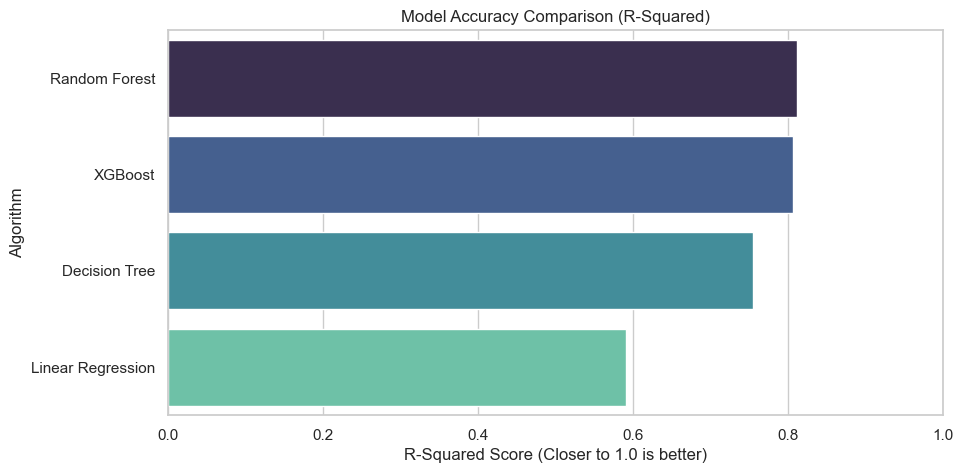

In [21]:
# --- PHASE 5: MODEL EVALUATION - VISUALIZATION ---

plt.figure(figsize=(10, 5))
# Sort the dataframe so the best model is at the top of the chart
results_df_sorted = results_df.sort_values(by='R-Squared (R2)', ascending=False)

sns.barplot(data=results_df_sorted, x='R-Squared (R2)', y='Model', palette='mako')
plt.title('Model Accuracy Comparison (R-Squared)')
plt.xlabel('R-Squared Score (Closer to 1.0 is better)')
plt.ylabel('Algorithm')
plt.xlim(0, 1)  # R-squared max is typically 1.0
plt.show()

 # Explainable AI (SHAP).

The Global Summary Plot

--- SHAP Summary Plot (Global Importance) ---


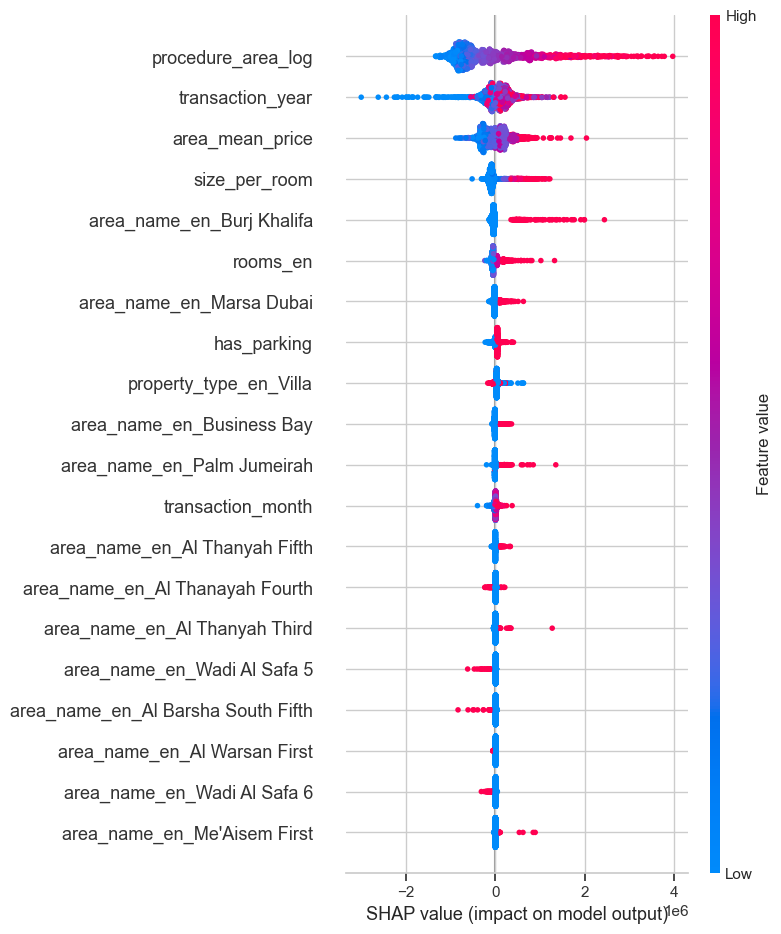

In [22]:
# --- PHASE 6: EXPLAINABLE AI (SHAP) - GLOBAL IMPORTANCE ---

# 1. Sample the test data to prevent memory crashes (2000 rows is plenty for SHAP)
X_sample = X_test.sample(2000, random_state=42)

# 2. Create the SHAP Explainer specifically for the winning XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# 3. Calculate the SHAP values for the sample
shap_values = explainer(X_sample)

# 4. Generate the SHAP Summary Plot
print("--- SHAP Summary Plot (Global Importance) ---")
# This plot shows which features push the price up (red) or down (blue)
shap.summary_plot(shap_values, X_sample)

The Local Waterfall Plot

--- Analyzing Property #0 ---
transaction_year              2.008000e+03
transaction_month             9.000000e+00
property_type_en_Villa        1.000000e+00
area_name_en_Palm Jumeirah    1.000000e+00
area_mean_price               4.478499e+06
procedure_area_log            5.744028e+00
size_per_room                 3.113200e+02
Name: 176737, dtype: float64


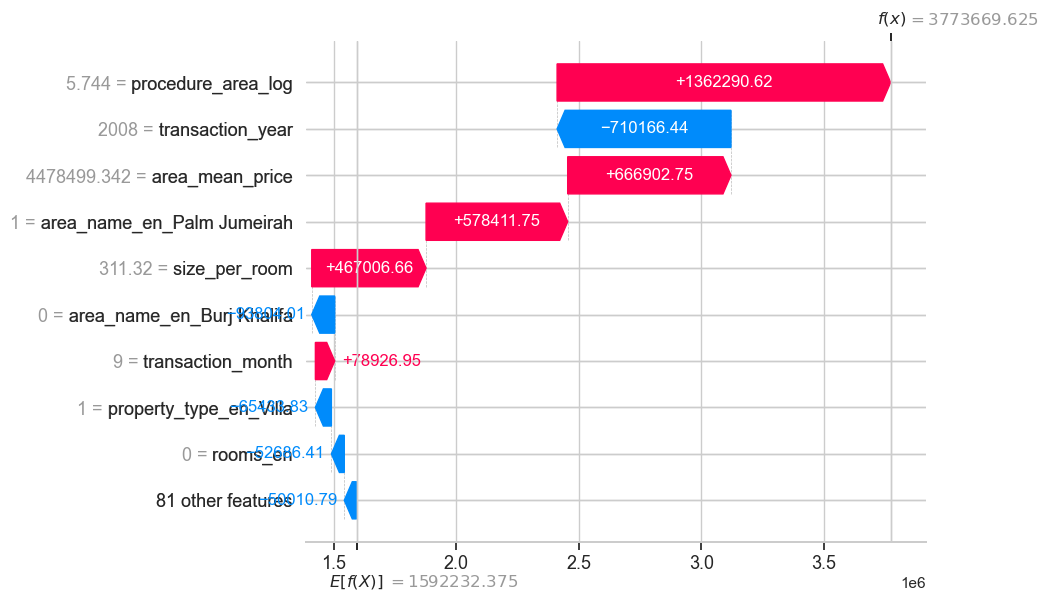

In [23]:
# --- PHASE 6: EXPLAINABLE AI (SHAP) - LOCAL EXPLANATION ---

# 1. Pick a single property from our sample (let's look at the very first one, index 0)
property_index = 0

# 2. Print the actual details of the property so we have context
print(f"--- Analyzing Property #{property_index} ---")
print(X_sample.iloc[property_index][X_sample.iloc[property_index] > 0]) # Only show non-zero features

# 3. Generate a Waterfall Plot for this specific property
# The waterfall plot shows exactly how the model arrived at its final price prediction
shap.plots.waterfall(shap_values[property_index], max_display=10)

# Streamlit Deployment

Model Export

In [25]:
# --- PHASE 7: MODEL EXPORT (UPDATED) ---

# 1. Save the NEW tuned XGBoost model
joblib.dump(xgb_model, 'dubai_xgb_model.pkl')

# 2. Save the NEW feature columns (now includes time features, log area etc.)
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

# 3. Save area mean price map (needed for Streamlit now)
area_price_map = df_clean.groupby('area_name_en')['actual_worth'].mean().to_dict()
joblib.dump(area_price_map, 'area_price_map.pkl')

print(f"Total features saved: {len(model_columns)}")
print("All files saved successfully ✅")
print(model_columns[:10])  # Preview first 10 columns to verify

Total features saved: 90
All files saved successfully ✅
['rooms_en', 'has_parking', 'transaction_year', 'transaction_month', 'property_type_en_Villa', 'area_name_en_Al Bada', 'area_name_en_Al Barsha First', 'area_name_en_Al Barsha Second', 'area_name_en_Al Barsha South Fifth', 'area_name_en_Al Barsha South Fourth']
